In [ ]:
pip install scikit-fem matplotlib numpy torch

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



plt.rcParams.update({
    "font.size": 14,        # 全部字體基準（ticks/labels/legend）
    "axes.titlesize": 16,   # title
    "axes.labelsize": 15,   # x/y label
    "xtick.labelsize": 13,  # x ticks
    "ytick.labelsize": 13,  # y ticks
    "legend.fontsize": 13,  # legend
})

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skfem import *
from skfem.helpers import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
from scipy.interpolate import griddata
import torch.nn.functional as F
import random
import os
import math

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Data generation

class GaussianMixture2D:
    """Generate a 2D Gaussian mixture function."""
    def __init__(self, n_gaussians=5, radius=1.0):
        self.n_gaussians = n_gaussians
        self.radius = radius
        self.params = self._generate_params()

    def _generate_params(self):
        """Randomly generate Gaussian parameters inside the disk."""
        params = {
            'amplitudes': np.random.uniform(-2.0, 2.0, self.n_gaussians),
            'centers': [],
            'sigmas': np.random.uniform(0.05, 0.2, self.n_gaussians) * self.radius
        }
        for _ in range(self.n_gaussians):
            r = np.random.uniform(0, 0.6 * self.radius)
            theta = np.random.uniform(0, 2 * np.pi)
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            params['centers'].append([x, y])
        params['centers'] = np.array(params['centers'])
        return params

    def evaluate(self, x, y):
        """Evaluate f(x, y)."""
        result = np.zeros_like(x)
        for i in range(self.n_gaussians):
            a_i = self.params['amplitudes'][i]
            c_i = self.params['centers'][i]
            sigma_i = self.params['sigmas'][i]
            dist_sq = (x - c_i[0])**2 + (y - c_i[1])**2
            result += a_i * np.exp(-dist_sq / (2 * sigma_i**2))
        return result


class CircularPoissonFEMSolver:
    """FEM solver for the Poisson equation on a circular domain."""
    def __init__(self, radius=1.0, n_refine=6):
        self.radius = radius
        m = MeshTri.init_circle(nrefs=n_refine)
        self.mesh = MeshTri(m.p * radius, m.t)
        self.basis = Basis(self.mesh, ElementTriP1())

    def solve(self, f_func):
        """Solve -Delta u = f on the circular domain with u = 0 on the boundary."""
        @BilinearForm
        def laplacian(u, v, _):
            return dot(grad(u), grad(v))

        @LinearForm
        def rhs(v, w):
            x, y = w.x
            f_values = f_func(x, y)
            return f_values * v

        K = laplacian.assemble(self.basis)
        f = rhs.assemble(self.basis)

        try:
            D = self.basis.get_dofs(self.mesh.boundary_facets())
        except Exception:
            D = self.basis.get_dofs()

        u_fem = solve(*condense(K, f, D=D))
        return u_fem

    def interpolate_to_grid(self, u_fem, nx=64, ny=64):
        """Interpolate the FEM solution to a regular grid; use nearest interpolation to fill linear-interpolation gaps; set values outside the disk to 0."""
        x = np.linspace(-self.radius, self.radius, nx)
        y = np.linspace(-self.radius, self.radius, ny)
        X, Y = np.meshgrid(x, y)

        fem_points = self.mesh.p.T
        pts_grid = np.column_stack([X.ravel(), Y.ravel()])

        u_lin = griddata(fem_points, np.asarray(u_fem), pts_grid, method='linear')
        u_lin = u_lin.reshape(ny, nx)

        if np.isnan(u_lin).any():
            u_nn = griddata(fem_points, np.asarray(u_fem), pts_grid, method='nearest')
            u_nn = u_nn.reshape(ny, nx)
            nan_mask = np.isnan(u_lin)
            u_lin[nan_mask] = u_nn[nan_mask]

        outside = (X**2 + Y**2) > (self.radius**2)
        u_lin[outside] = 0.0

        return u_lin.astype(np.float32), X, Y


class CircularDatasetGenerator:
    """Generate a dataset on the circular domain."""
    def __init__(self, n_samples=1000, radius=1.0, nx=64, ny=64, n_gaussians_range=(3, 8)):
        self.n_samples = n_samples
        self.radius = radius
        self.nx = nx
        self.ny = ny
        self.n_gaussians_range = n_gaussians_range
        self.solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)

    def generate_dataset(self):
        dataset = {'f': [], 'u': [], 'params': [], 'mask': None}
        print(f"Generating {self.n_samples} samples on circular domain...")

        x = np.linspace(-self.radius, self.radius, self.nx)
        y = np.linspace(-self.radius, self.radius, self.ny)
        X, Y = np.meshgrid(x, y)
        mask = X**2 + Y**2 <= self.radius**2
        dataset['mask'] = mask.astype(np.float32)

        for i in range(self.n_samples):
            if (i + 1) % 100 == 0:
                print(f"  Progress: {i+1}/{self.n_samples}")

            n_gaussians = np.random.randint(*self.n_gaussians_range)
            gm = GaussianMixture2D(n_gaussians=n_gaussians, radius=self.radius)

            def f_func(xq, yq):
                return gm.evaluate(xq, yq)

            u_fem = self.solver.solve(f_func)
            u_grid, X, Y = self.solver.interpolate_to_grid(u_fem, self.nx, self.ny)

            f_grid = gm.evaluate(X, Y).astype(np.float32)
            f_grid[~mask] = 0.0

            dataset['f'].append(f_grid)
            dataset['u'].append(u_grid)
            dataset['params'].append(gm.params)

        dataset['f'] = np.array(dataset['f'], dtype=np.float32)
        dataset['u'] = np.array(dataset['u'], dtype=np.float32)

        print("Dataset generation complete!")
        return dataset

    def save_dataset(self, dataset, filename='circular_poisson_dataset.npz'):
        np.savez_compressed(filename, f=dataset['f'], u=dataset['u'], mask=dataset['mask'])
        with open(filename.replace('.npz', '_params.pkl'), 'wb') as file:
            pickle.dump(dataset['params'], file)
        print(f"Dataset saved to {filename}")



class PoissonDataset(Dataset):
    def __init__(self, f, u, mask):
        self.f = torch.from_numpy(f).float()
        self.u = torch.from_numpy(u).float()
        self.mask = torch.from_numpy(mask).float()  # Shape: (H, W)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, idx):
        return self.f[idx], self.u[idx], self.mask

def masked_mse(pred, target, mask):
    if mask.dim() == 2:
        mask = mask.unsqueeze(0).expand_as(pred)
    num = ((pred - target) ** 2 * mask).sum()
    den = mask.sum().clamp_min(1.0)
    return num / den


def masked_rel_l2(pred, target, mask):
    if mask.dim() == 2:
        mask = mask.unsqueeze(0).expand_as(pred)
    num = (((pred - target) ** 2) * mask).sum().sqrt()
    den = ((target ** 2) * mask).sum().sqrt().clamp_min(1e-12)
    return num / den


def make_coords(grid_size, radius, device):
    xv = torch.linspace(-radius, radius, grid_size, device=device)
    yv = torch.linspace(-radius, radius, grid_size, device=device)
    Yg, Xg = torch.meshgrid(yv, xv, indexing='ij')
    return torch.stack([Xg.flatten(), Yg.flatten()], dim=1)


def count_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters())

def generate_test_data_different_mesh(params_list, grid_size, radius=1.0):
    solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)
    x = np.linspace(-radius, radius, grid_size)
    y = np.linspace(-radius, radius, grid_size)
    X, Y = np.meshgrid(x, y)
    mask = (X**2 + Y**2) <= radius**2

    f_list, u_list = [], []
    print(f"  Generating data on {grid_size}x{grid_size} grid...")
    for i, params in enumerate(params_list):
        if (i + 1) % 20 == 0:
            print(f"    Progress: {i+1}/{len(params_list)}")

        gm = GaussianMixture2D(n_gaussians=len(params['amplitudes']), radius=radius)
        gm.params = params

        def f_func(xq, yq):
            return gm.evaluate(xq, yq)

        u_fem = solver.solve(f_func)
        u_grid, _, _ = solver.interpolate_to_grid(u_fem, grid_size, grid_size)
        np.nan_to_num(u_grid, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

        f_grid = gm.evaluate(X, Y).astype(np.float32)
        f_grid[~mask] = 0.0

        f_list.append(f_grid.astype(np.float32))
        u_list.append(u_grid.astype(np.float32))

    return np.array(f_list), np.array(u_list), mask.astype(np.float32)



In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class FourierFeatures(nn.Module):
    def __init__(self, in_dim: int, n_ff: int = 32, kind: str = 'gauss',
                 sigma: float = 4.0, scale: float = math.pi, include_input: bool = True):
        super().__init__()
        self.in_dim = in_dim
        self.n_ff = n_ff
        self.kind = kind
        self.sigma = sigma
        self.scale = scale
        self.include_input = include_input

        if kind == 'gauss':
            B = torch.randn(in_dim, n_ff) * sigma
            self.register_buffer('B', B)
        elif kind == 'log2':
            freqs = (2.0 ** torch.arange(n_ff)) * scale
            self.register_buffer('freqs', freqs)
        else:
            raise ValueError("kind must be one of {'gauss', 'log2'}.")

    @property
    def out_dim(self):
        base = self.in_dim if self.include_input else 0
        if self.kind == 'gauss':
            return base + 2 * self.n_ff
        else:
            return base + 2 * self.n_ff * self.in_dim

    def forward(self, x):
        # x: (..., in_dim)
        if self.kind == 'gauss':
            proj = x @ self.B
            enc = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        else:
            parts = []
            for d in range(self.in_dim):
                xd = x[..., d:d+1] * self.freqs
                parts.append(torch.sin(xd))
                parts.append(torch.cos(xd))
            enc = torch.cat(parts, dim=-1)

        if self.include_input:
            return torch.cat([x, enc], dim=-1)
        return enc


class FeedForward(nn.Module):
    def __init__(self, d_model, ff_mult=4, dropout=0.1):
        super().__init__()
        hidden = int(d_model * ff_mult)
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, ff_mult=ff_mult, dropout=dropout)

    def forward(self, x):
        h = self.ln1(x)
        attn_out, _ = self.attn(h, h, h, need_weights=False)
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x


class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.ln_q = nn.LayerNorm(d_model)
        self.ln_ctx = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, ff_mult=ff_mult, dropout=dropout)

    def forward(self, x, context, key_padding_mask=None):
        q = self.ln_q(x)
        ctx = self.ln_ctx(context)
        attn_out, _ = self.attn(
            q, ctx, ctx,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x


class OperatorTransformer2D(nn.Module):
    """
      input tokens [f, x, y, mask]
        -> input projection
        -> cross-attn into latent tokens
        -> latent self-attention blocks
        -> query tokens [x, y, mask]
        -> cross-attn from latents
        -> scalar output u(x,y)
    """
    def __init__(self,
                 radius=1.0,
                 d_model=128,
                 n_heads=4,
                 n_latents=128,
                 n_layers=4,
                 ff_mult=4,
                 dropout=0.1,
                 use_fourier=True,
                 ff_kind='gauss',
                 ff_n=32,
                 ff_sigma=4.0,
                 ff_scale=math.pi,
                 ff_include_input=True):
        super().__init__()
        self.radius = radius
        self.d_model = d_model
        self.n_latents = n_latents

        self.coord_ff = None
        coord_dim = 2
        if use_fourier:
            self.coord_ff = FourierFeatures(
                in_dim=2,
                n_ff=ff_n,
                kind=ff_kind,
                sigma=ff_sigma,
                scale=ff_scale,
                include_input=ff_include_input
            )
            coord_dim = self.coord_ff.out_dim

        # input token: [f, mask, coord_feat]
        self.input_proj = nn.Linear(1 + 1 + coord_dim, d_model)

        # query token: [mask, coord_feat]
        self.query_proj = nn.Linear(1 + coord_dim, d_model)

        # learnable latent tokens
        self.latents = nn.Parameter(torch.randn(n_latents, d_model) * 0.02)

        self.input_cross = CrossAttentionBlock(
            d_model=d_model,
            n_heads=n_heads,
            ff_mult=ff_mult,
            dropout=dropout
        )

        self.latent_blocks = nn.ModuleList([
            SelfAttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                ff_mult=ff_mult,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        self.output_cross = CrossAttentionBlock(
            d_model=d_model,
            n_heads=n_heads,
            ff_mult=ff_mult,
            dropout=dropout
        )

        self.out_norm = nn.LayerNorm(d_model)
        self.out_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1)
        )

        self._grid_cache = {}

    def _get_grid_features(self, H, W, device):
        key = (H, W, device.type, device.index if device.index is not None else -1)
        if key in self._grid_cache:
            return self._grid_cache[key]

        xv = torch.linspace(-self.radius, self.radius, W, device=device)
        yv = torch.linspace(-self.radius, self.radius, H, device=device)
        Y, X = torch.meshgrid(yv, xv, indexing='ij')

        coords = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)     # (N, 2)
        mask = ((X**2 + Y**2) <= self.radius**2).float().reshape(-1, 1)  # (N, 1)

        if self.coord_ff is not None:
            coord_feat = self.coord_ff(coords.unsqueeze(0)).squeeze(0)    # (N, D)
        else:
            coord_feat = coords

        self._grid_cache[key] = (coords, mask, coord_feat)
        return coords, mask, coord_feat

    def forward(self, f, mask=None):
        """
        f:    (B, H, W)
        mask: (H, W) or (B, H, W)
        """
        B, H, W = f.shape
        device = f.device
        _, grid_mask, coord_feat = self._get_grid_features(H, W, device)

        if mask is None:
            mask = grid_mask.view(H, W)
        if mask.dim() == 2:
            mask = mask.unsqueeze(0).expand(B, -1, -1)

        f_flat = f.reshape(B, -1, 1)                 # (B, N, 1)
        mask_flat = mask.reshape(B, -1, 1)           # (B, N, 1)
        coord_feat_b = coord_feat.unsqueeze(0).expand(B, -1, -1)

        # input tokens
        inp = torch.cat([f_flat, mask_flat, coord_feat_b], dim=-1)  # (B, N, Din)
        inp = self.input_proj(inp)

        # cross-attention: latents attend to input tokens
        latents = self.latents.unsqueeze(0).expand(B, -1, -1)       # (B, L, d)
        key_padding_mask = (mask_flat.squeeze(-1) < 0.5)             # True 表示忽略
        latents = self.input_cross(latents, inp, key_padding_mask=key_padding_mask)

        # latent self-attention
        for blk in self.latent_blocks:
            latents = blk(latents)

        # query tokens
        queries = torch.cat([mask_flat, coord_feat_b], dim=-1)       # (B, N, Dq)
        queries = self.query_proj(queries)

        # query every output point from latents
        out = self.output_cross(queries, latents)                    # (B, N, d)
        out = self.out_head(self.out_norm(out)).squeeze(-1)          # (B, N)
        out = out.view(B, H, W)

        # The outer edge of the circle is directly pressed into 0.
        out = out * mask
        return out

In [ ]:
def evaluate_epoch_mse_transformer(model, data_loader, device='cuda'):
    """
    The aggregated masked MSE is calculated using the entire data_loader.
    draw train / val curve。
    """
    model.eval()
    err2_sum = 0.0
    pix_sum = 0.0

    with torch.no_grad():
        for f, u, mask in data_loader:
            f = f.to(device)
            u = u.to(device)
            mask = mask.to(device)

            pred = model(f, mask=mask)

            if mask.dim() == 2:
                mask_b = mask.unsqueeze(0).expand_as(pred)
            else:
                mask_b = mask

            err2_sum += torch.sum(((pred - u) ** 2) * mask_b).item()
            pix_sum += torch.sum(mask_b).item()

    return err2_sum / max(pix_sum, 1.0)


def evaluate_loader_transformer(model, data_loader, device='cuda'):

    model.eval()
    err2_sum = 0.0
    tgt2_sum = 0.0
    pix_sum = 0.0

    with torch.no_grad():
        for f, u, mask in data_loader:
            f = f.to(device)
            u = u.to(device)
            mask = mask.to(device)

            if mask.dim() == 2:
                mask_b = mask.unsqueeze(0).expand(f.size(0), -1, -1)
            else:
                mask_b = mask

            pred = model(f, mask=mask)

            diff = (pred - u) * mask_b
            err2_sum += torch.sum(diff ** 2).item()
            tgt2_sum += torch.sum((u * mask_b) ** 2).item()
            pix_sum += torch.sum(mask_b).item()

    mse = err2_sum / max(pix_sum, 1.0)
    rel_l2 = (err2_sum ** 0.5) / (max(tgt2_sum, 1e-12) ** 0.5)
    return mse, rel_l2


def train_transformer(model, train_loader, val_loader, train_eval_loader=None,
                      epochs=100, lr=1e-3, device='cuda',
                      save_best_path='best_transformer.pt'):

    if train_eval_loader is None:
        train_eval_loader = train_loader

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    train_losses = []
    val_losses = []
    best_val = float('inf')

    for epoch in range(epochs):
        model.train()

        for f, u, mask in train_loader:
            f = f.to(device)
            u = u.to(device)
            mask = mask.to(device)

            optimizer.zero_grad()
            pred = model(f, mask=mask)
            loss = masked_mse(pred, u, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        train_loss = evaluate_epoch_mse_transformer(model, train_eval_loader, device=device)
        val_loss = evaluate_epoch_mse_transformer(model, val_loader, device=device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_best_path)

        scheduler.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"[Transformer] Epoch {epoch+1:3d}/{epochs} | "
                  f"Train {train_loss:.6e} | "
                  f"Val {val_loss:.6e} | "
                  f"LR {current_lr:.2e}")

    print(f"✓ Best validation model saved to {save_best_path} (best val = {best_val:.6e})")
    return train_losses, val_losses


def plot_train_val_transformer(train_losses, val_losses, out='transformer_train_val_curve.png'):
    plt.figure(figsize=(7.5, 4))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train (eval mode)')
    plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Masked MSE')
    plt.title('Transformer Training and Validation Curves')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved train/val curve to {out}")

In [ ]:
def test_mesh_invariance_transformer(model, test_params,
                                     test_grid_sizes=[32, 48, 64, 80, 96, 128],
                                     train_grid_size=64, device='cuda', radius=1.0):
    print("\n" + "="*60)
    print("MESH INVARIANCE TEST (Transformer only)")
    print("="*60)
    print(f"Training grid size: {train_grid_size}x{train_grid_size}")
    print(f"Test grid sizes: {test_grid_sizes}")

    model.eval()
    results = {'grid_sizes': test_grid_sizes, 'transformer': {'mse': [], 'rel_error': []}}

    for grid_size in test_grid_sizes:
        print(f"\nTesting on {grid_size}x{grid_size} grid...")
        f_test, u_test, mask = generate_test_data_different_mesh(test_params, grid_size, radius=radius)

        f_tensor = torch.from_numpy(f_test).to(device)
        u_tensor = torch.from_numpy(u_test).to(device)
        mask_tensor = torch.from_numpy(mask).to(device)

        with torch.no_grad():
            pred = model(f_tensor, mask=mask_tensor)
            mse = masked_mse(pred, u_tensor, mask_tensor).item()
            rel = masked_rel_l2(pred, u_tensor, mask_tensor).item()

        results['transformer']['mse'].append(mse)
        results['transformer']['rel_error'].append(rel)

        print(f"  Transformer - MSE: {mse:.8f}, Rel Error: {rel:.8f}")

    return results


def plot_mesh_invariance_results_transformer(results, train_grid_size=64):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    grid_sizes = results['grid_sizes']
    xticks = sorted(set(list(grid_sizes) + [train_grid_size]))

    for ax in axes:
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(int(x)) for x in xticks])
        ax.margins(x=0.02)

    axes[0].plot(
        grid_sizes, results['transformer']['mse'],
        '^-', label='Transformer', linewidth=2, markersize=8
    )
    axes[0].axvline(
        train_grid_size, color='gray', linestyle='--',
        alpha=0.7, label=f'Training size ({train_grid_size})'
    )
    axes[0].set_xlabel('Grid Size')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].set_title('MSE vs Grid Size (Transformer)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

    axes[1].plot(
        grid_sizes, results['transformer']['rel_error'],
        '^-', label='Transformer', linewidth=2, markersize=8
    )
    axes[1].axvline(
        train_grid_size, color='gray', linestyle='--',
        alpha=0.7, label=f'Training size ({train_grid_size})'
    )
    axes[1].set_xlabel('Grid Size')
    axes[1].set_ylabel('Relative L2 Error')
    axes[1].set_title('Relative Error vs Grid Size (Transformer)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig('mesh_invariance_results_transformer.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Mesh invariance results saved to mesh_invariance_results_transformer.png")

In [ ]:
def plot_examples_transformer(model: nn.Module, dataset: Dataset, device='cuda',
                              idxs=None, n_show=3, radius=1.0,
                              cmap_f='viridis', cmap_u='viridis', cmap_diff='RdBu_r',
                              out_path='transformer_examples.png'):
    model.eval()
    N = len(dataset)
    if idxs is None:
        if n_show >= N:
            idxs = list(range(N))
        else:
            idxs = np.linspace(0, N - 1, n_show, dtype=int).tolist()
    else:
        idxs = sorted(set([i for i in idxs if 0 <= i < N]))
        if len(idxs) == 0:
            raise ValueError("idxs are out of bounds, please provide valid indexes.")

    rows = len(idxs)
    cols = 4
    plt.figure(figsize=(4.2 * cols, 4.2 * rows), dpi=120)

    with torch.no_grad():
        for r, i in enumerate(idxs):
            f, u, mask = dataset[i]
            H, W = f.shape[-2], f.shape[-1]
            f_np = f.numpy()
            u_np = u.numpy()
            mask_b = mask.numpy() > 0.5

            pred = model(
                f.unsqueeze(0).to(device),
                mask=mask.to(device)
            ).reshape(1, H, W).squeeze(0).detach().cpu().numpy()

            u_inside = np.where(mask_b, u_np, np.nan)
            pred_inside = np.where(mask_b, pred, np.nan)

            umin = np.nanmin([np.nanmin(u_inside), np.nanmin(pred_inside)])
            umax = np.nanmax([np.nanmax(u_inside), np.nanmax(pred_inside)])
            if not np.isfinite(umin) or not np.isfinite(umax) or umin == umax:
                umin, umax = -1.0, 1.0

            diff = np.where(mask_b, pred - u_np, np.nan)
            ad = np.nanmax(np.abs(diff))
            dlim = 1e-12 if (not np.isfinite(ad) or ad == 0.0) else ad

            ax = plt.subplot(rows, cols, r * cols + 1)
            im = ax.imshow(np.ma.masked_where(~mask_b, f_np), origin='lower',
                           interpolation='nearest', cmap=cmap_f)
            ax.set_title(f"[{i}] f")
            ax.set_xticks([]); ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            ax = plt.subplot(rows, cols, r * cols + 2)
            im = ax.imshow(np.ma.masked_where(~mask_b, u_np), origin='lower',
                           interpolation='nearest', cmap=cmap_u, vmin=umin, vmax=umax)
            ax.set_title("u (FEM truth)")
            ax.set_xticks([]); ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            ax = plt.subplot(rows, cols, r * cols + 3)
            im = ax.imshow(np.ma.masked_where(~mask_b, pred), origin='lower',
                           interpolation='nearest', cmap=cmap_u, vmin=umin, vmax=umax)
            ax.set_title("û (Transformer)")
            ax.set_xticks([]); ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            ax = plt.subplot(rows, cols, r * cols + 4)
            im = ax.imshow(np.ma.masked_where(~mask_b, diff), origin='lower',
                           interpolation='nearest', vmin=-dlim, vmax=dlim, cmap=cmap_diff)
            mse_val = np.nanmean(((pred - u_np) ** 2)[mask_b])
            rel_val = (np.sqrt(np.nansum(((pred - u_np) ** 2)[mask_b])) /
                       max(np.sqrt(np.nansum((u_np ** 2)[mask_b])), 1e-12))
            ax.set_title(f"û − u\n(MSE={mse_val:.2e}, Rel={rel_val:.3f})")
            ax.set_xticks([]); ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved example panel to {out_path}")

Circular Domain Poisson Equation: Transformer (only)
with Mesh Invariance Testing
📂 Loading existing dataset...
✓ Loaded 1000 samples

[2/6] Preparing data loaders...
Total samples : 1000
Train samples : 800
Val samples   : 100
Test samples  : 100
Batch size    : 16
Steps/epoch   : 50

[3/6] Training Transformer on cuda...
Transformer parameters: 184,833
[Transformer] Epoch   1/100 | Train 9.551433e-04 | Val 9.587649e-04 | LR 1.00e-03
[Transformer] Epoch  10/100 | Train 1.405095e-04 | Val 1.208894e-04 | LR 1.00e-03
[Transformer] Epoch  20/100 | Train 8.494198e-05 | Val 7.927481e-05 | LR 1.00e-03
[Transformer] Epoch  30/100 | Train 5.448296e-05 | Val 5.028080e-05 | LR 1.00e-03
[Transformer] Epoch  40/100 | Train 1.057946e-05 | Val 1.118825e-05 | LR 1.00e-03
[Transformer] Epoch  50/100 | Train 1.320769e-05 | Val 1.240728e-05 | LR 5.00e-04
[Transformer] Epoch  60/100 | Train 4.784993e-06 | Val 4.997451e-06 | LR 5.00e-04
[Transformer] Epoch  70/100 | Train 5.148135e-06 | Val 5.216202e-06 |

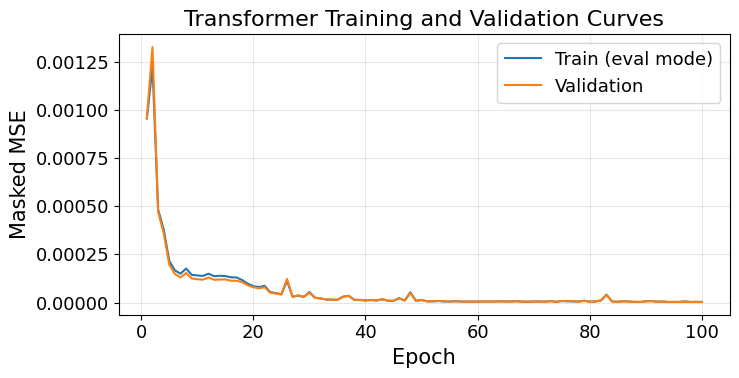

✓ Saved train/val curve to transformer_train_val_curve.png
✓ Loaded best validation checkpoint.

[4/6] Evaluating on TEST set (same grid as training)...
✓ TEST MSE: 0.000003
✓ TEST Relative L2: 0.065570
✓ Saved to transformer_test_metrics.txt

[5/6] Plotting example predictions...


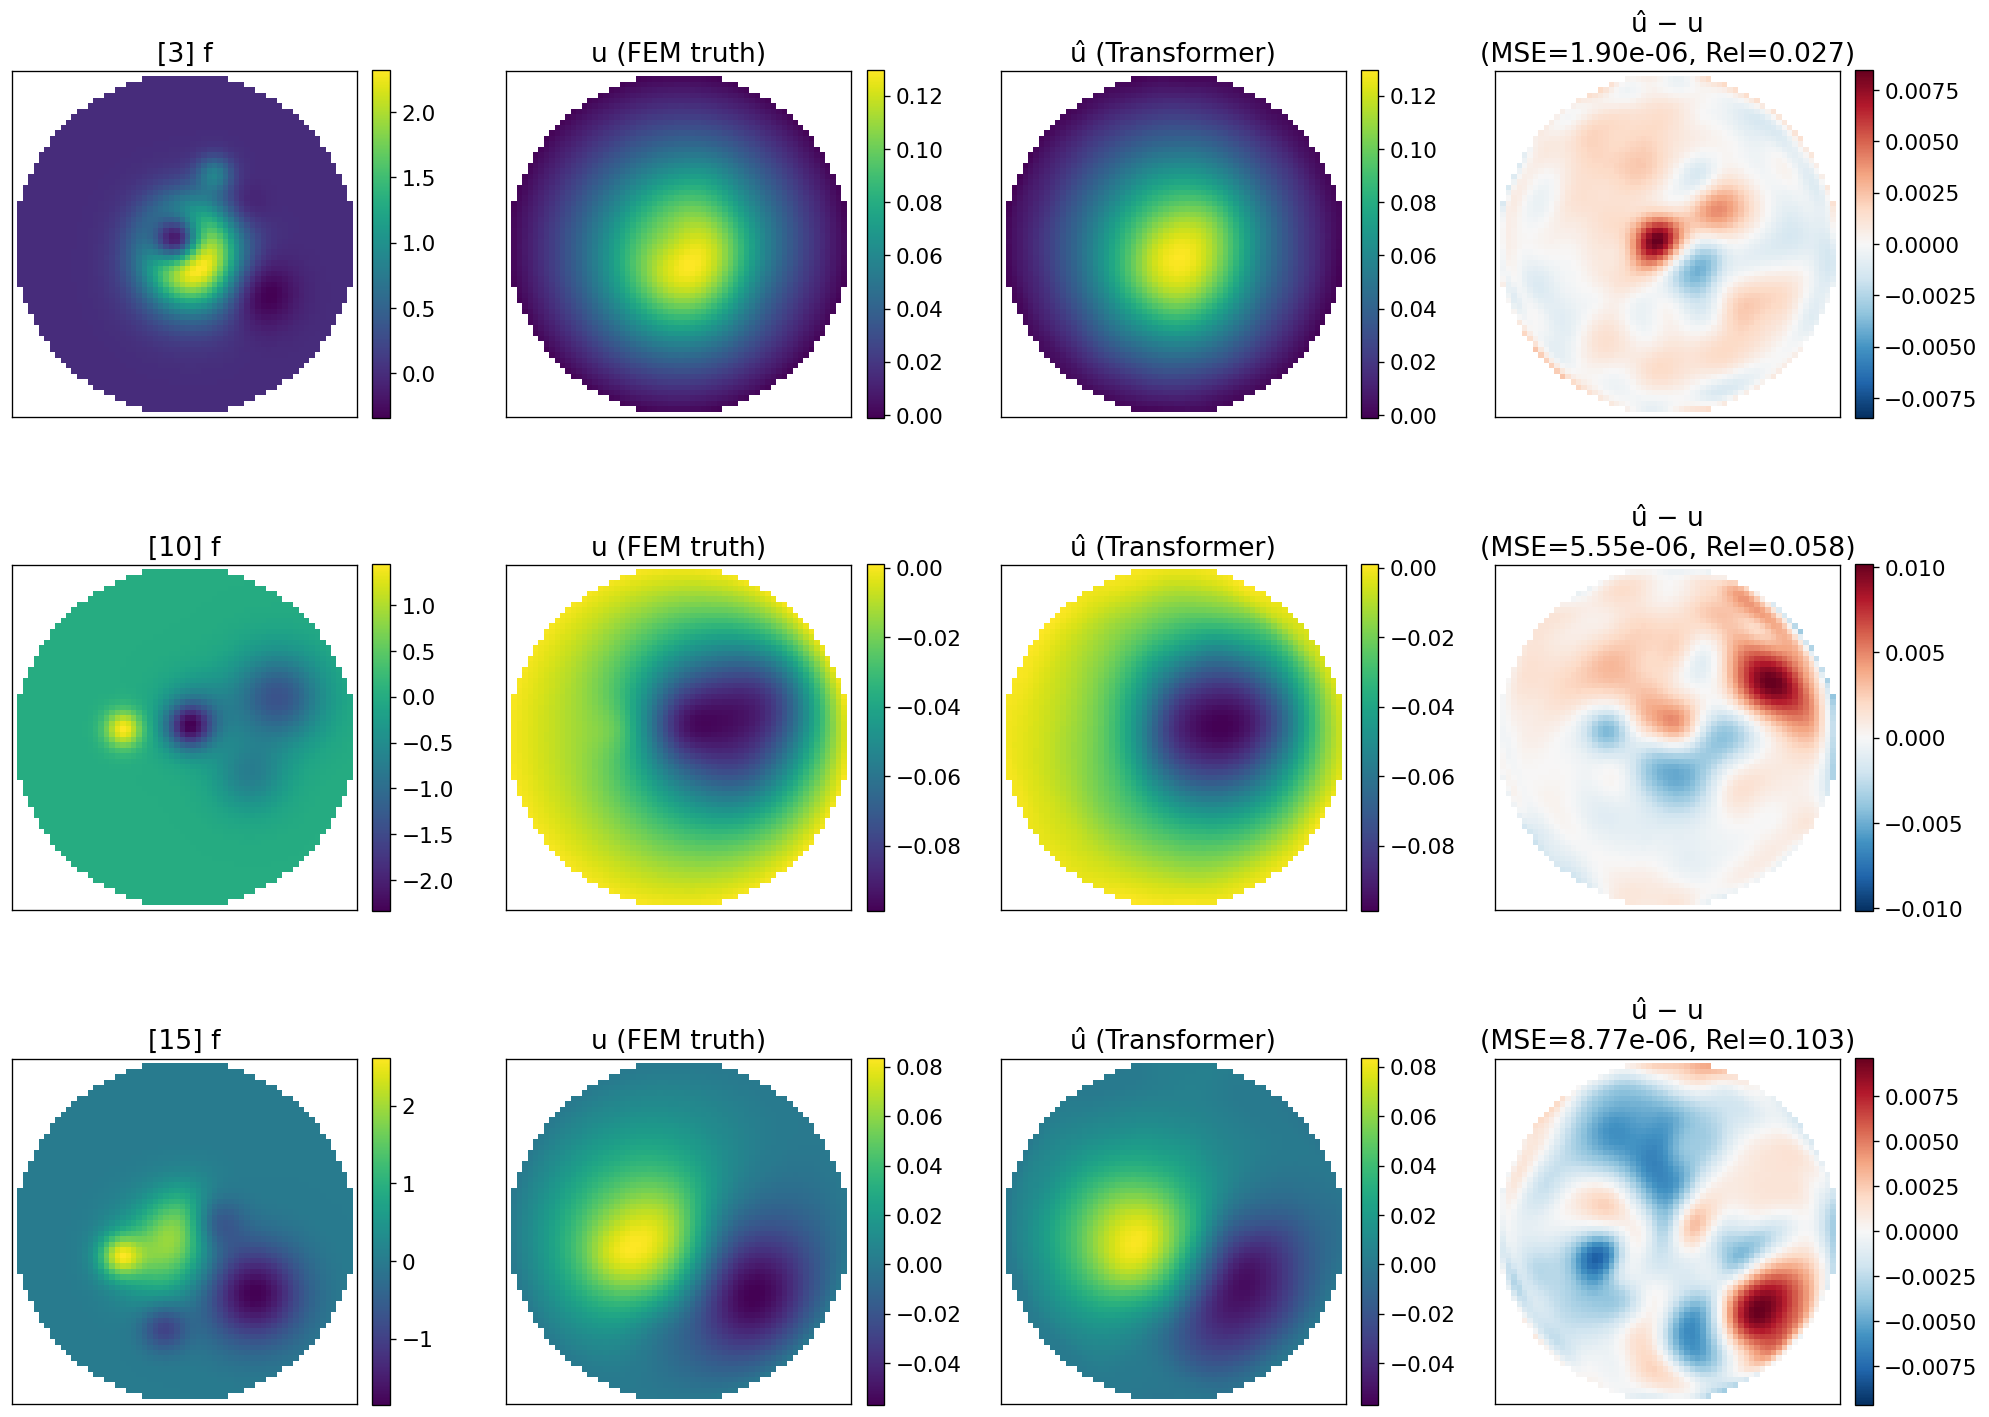

✓ Saved example panel to transformer_examples.png

[6/6] Testing mesh invariance (Transformer only)...

MESH INVARIANCE TEST (Transformer only)
Training grid size: 64x64
Test grid sizes: [32, 48, 64, 80, 96, 128]

Testing on 32x32 grid...
  Generating data on 32x32 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/100
    Progress: 80/100
    Progress: 100/100
  Transformer - MSE: 0.00000350, Rel Error: 0.06527507

Testing on 48x48 grid...
  Generating data on 48x48 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/100
    Progress: 80/100
    Progress: 100/100
  Transformer - MSE: 0.00000349, Rel Error: 0.06539764

Testing on 64x64 grid...
  Generating data on 64x64 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/100
    Progress: 80/100
    Progress: 100/100
  Transformer - MSE: 0.00000349, Rel Error: 0.06556982

Testing on 80x80 grid...
  Generating data on 80x80 grid...
    Progress: 20/100
    Progress: 40/100
    Progress: 60/1

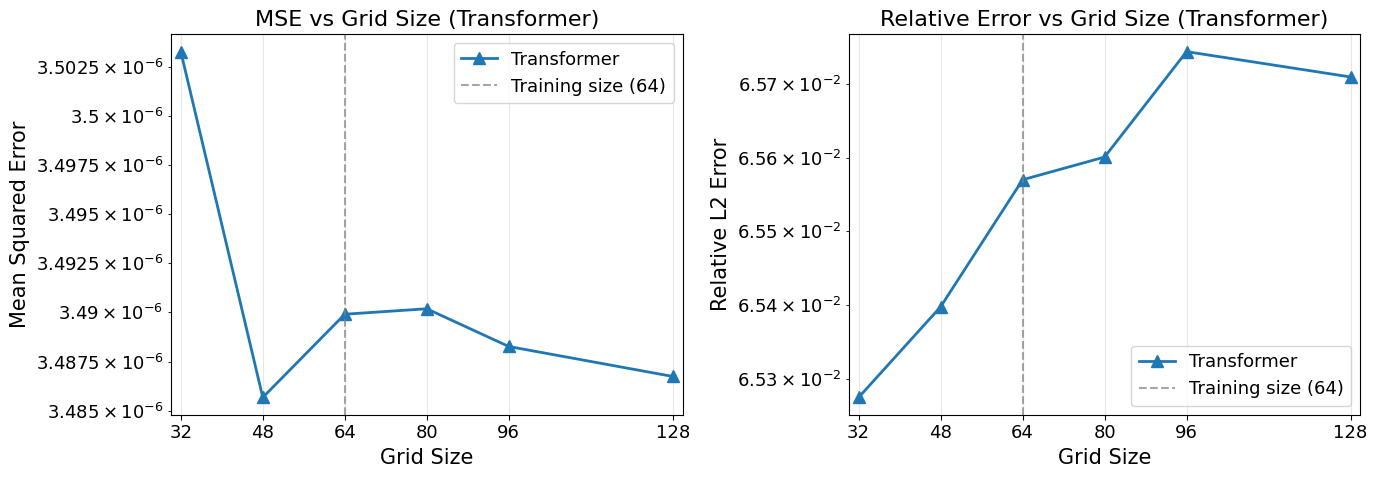


✓ Mesh invariance results saved to mesh_invariance_results_transformer.png

MESH INVARIANCE SUMMARY (Transformer)

Grid 32x32:
  Transformer - MSE: 0.000004, Rel Error: 0.065275

Grid 48x48:
  Transformer - MSE: 0.000003, Rel Error: 0.065398

Grid 64x64:
  Transformer - MSE: 0.000003, Rel Error: 0.065570

Grid 80x80:
  Transformer - MSE: 0.000003, Rel Error: 0.065601

Grid 96x96:
  Transformer - MSE: 0.000003, Rel Error: 0.065744

Grid 128x128:
  Transformer - MSE: 0.000003, Rel Error: 0.065710

✓ All done (Transformer only)!


In [ ]:
if __name__ == "__main__":
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    N_SAMPLES = 1000
    GRID_SIZE = 64
    BATCH_SIZE = 16
    EPOCHS = 100
    RADIUS = 1.0

    TEST_GRID_SIZES = [32, 48, 64, 80, 96, 128]
    N_MESH_TEST_SAMPLES = 100

    print("="*60)
    print("Circular Domain Poisson Equation: Transformer (only)")
    print("with Mesh Invariance Testing")
    print("="*60)

    # Load or generate data
    dataset_file = 'circular_poisson_dataset.npz'
    params_file = dataset_file.replace('.npz', '_params.pkl')

    if os.path.exists(dataset_file) and os.path.exists(params_file):
        print("📂 Loading existing dataset...")
        data = np.load(dataset_file)
        dataset = {'f': data['f'], 'u': data['u'], 'mask': data['mask']}
        with open(params_file, 'rb') as file:
            dataset['params'] = pickle.load(file)
        print(f"✓ Loaded {len(dataset['f'])} samples")
    else:
        print("🔄 Generating new dataset...")
        generator = CircularDatasetGenerator(
            n_samples=N_SAMPLES,
            nx=GRID_SIZE,
            ny=GRID_SIZE,
            radius=RADIUS
        )
        dataset = generator.generate_dataset()
        generator.save_dataset(dataset, filename=dataset_file)

    # Data loaders
    print("\n[2/6] Preparing data loaders...")
    N_TOTAL = len(dataset['f'])
    n_train = int(0.8 * N_TOTAL)
    n_val   = int(0.1 * N_TOTAL)
    n_test  = int(0.1 * N_TOTAL)
    train_dataset = PoissonDataset(dataset['f'][:n_train], dataset['u'][:n_train], dataset['mask'])
    val_dataset   = PoissonDataset(dataset['f'][n_train:n_train+n_val], dataset['u'][n_train:n_train+n_val], dataset['mask'])
    test_dataset  = PoissonDataset(dataset['f'][-n_test:], dataset['u'][-n_test:], dataset['mask'])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Total samples : {N_TOTAL}")
    print(f"Train samples : {len(train_dataset)}")
    print(f"Val samples   : {len(val_dataset)}")
    print(f"Test samples  : {len(test_dataset)}")
    print(f"Batch size    : {BATCH_SIZE}")
    print(f"Steps/epoch   : {len(train_loader)}")

    # Build the Transformer
    print(f"\n[3/6] Training Transformer on {DEVICE}...")
    transformer = OperatorTransformer2D(
        radius=RADIUS,
        d_model=64,
        n_heads=4,
        n_latents=128,
        n_layers=3,
        ff_mult=2,
        dropout=0.1,
        use_fourier=True,
        ff_kind='gauss',
        ff_n=16,
        ff_sigma=4.0,
        ff_scale=math.pi,
        ff_include_input=True
    ).to(DEVICE)

    print(f"Transformer parameters: {count_params(transformer):,d}")

    tr_train_loss, tr_val_loss = train_transformer(
        transformer,
        train_loader,
        val_loader,
        train_eval_loader=train_eval_loader,
        epochs=EPOCHS,
        device=DEVICE,
        save_best_path='best_transformer.pt'
    )

    plot_train_val_transformer(
        tr_train_loss,
        tr_val_loss,
        out='transformer_train_val_curve.png'
    )

    # Load the best model
    transformer.load_state_dict(torch.load('best_transformer.pt', map_location=DEVICE))
    transformer.to(DEVICE)
    transformer.eval()
    print("✓ Loaded best validation checkpoint.")

    # Test set final metrics
    print("\n[4/6] Evaluating on TEST set (same grid as training)...")
    test_mse, test_rel = evaluate_loader_transformer(transformer, test_loader, device=DEVICE)
    print(f"✓ TEST MSE: {test_mse:.6f}")
    print(f"✓ TEST Relative L2: {test_rel:.6f}")

    with open('transformer_test_metrics.txt', 'w') as f:
        f.write(f"TEST MSE: {test_mse:.8f}\n")
        f.write(f"TEST Relative L2: {test_rel:.8f}\n")
    print("✓ Saved to transformer_test_metrics.txt")

    # Visualization
    print("\n[5/6] Plotting example predictions...")
    plot_examples_transformer(
        transformer, test_dataset, device=DEVICE,
        idxs=[3, 10, 15], n_show=3, radius=RADIUS,
        cmap_f='viridis', cmap_u='viridis', cmap_diff='RdBu_r',
        out_path='transformer_examples.png'
    )

    # Mesh invariance
    print("\n[6/6] Testing mesh invariance (Transformer only)...")
    max_avail = len(dataset['params']) - (n_train + n_val)
    n_mesh_test_samples = min(N_MESH_TEST_SAMPLES, max_avail)
    test_params = dataset['params'][n_train+n_val : n_train+n_val+n_mesh_test_samples]

    mesh_results = test_mesh_invariance_transformer(
        transformer,
        test_params,
        test_grid_sizes=TEST_GRID_SIZES,
        train_grid_size=GRID_SIZE,
        device=DEVICE,
        radius=RADIUS
    )

    print("\nPlotting mesh invariance results...")
    plot_mesh_invariance_results_transformer(mesh_results, train_grid_size=GRID_SIZE)

    print("\n" + "="*60)
    print("MESH INVARIANCE SUMMARY (Transformer)")
    print("="*60)
    for i, grid_size in enumerate(TEST_GRID_SIZES):
        print(f"\nGrid {grid_size}x{grid_size}:")
        print(f"  Transformer - MSE: {mesh_results['transformer']['mse'][i]:.6f}, "
              f"Rel Error: {mesh_results['transformer']['rel_error'][i]:.6f}")

    print("\n✓ All done (Transformer only)!")


In [ ]:
# OOD test

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def make_sin_cos_sum(specs, use_pi=True):

    fac = np.pi if use_pi else 1.0
    def f(x, y):
        v = np.zeros_like(x, dtype=np.float64)
        for (amp, xk, kx, phx, yk, ky, phy) in specs:
            gx = np.sin(fac * kx * x + phx) if xk == 'sin' else np.cos(fac * kx * x + phx)
            gy = np.sin(fac * ky * y + phy) if yk == 'sin' else np.cos(fac * ky * y + phy)
            v += amp * gx * gy
        return v
    return f


def make_x_only_sin(k, amp=1.0, phase=0.0, use_pi=True):

    fac = np.pi if use_pi else 1.0
    def f(x, y):
        return amp * np.sin(fac * k * x + phase)
    return f


def manufactured_u_star():
    def u_star(x, y):
        r2 = x**2 + y**2
        return (1.0 - r2)**2

    def f_star(x, y):
        r2 = x**2 + y**2
        return 8.0 - 16.0 * r2

    return f_star, u_star


def solve_truth_on_grid(solver, f_func, grid_size=64, radius=1.0):
    u_fem = solver.solve(f_func)
    u_grid, X, Y = solver.interpolate_to_grid(u_fem, grid_size, grid_size)

    f_grid = f_func(X, Y).astype(np.float32)
    mask = (X**2 + Y**2) <= radius**2
    f_grid[~mask] = 0.0

    return f_grid, u_grid.astype(np.float32), mask.astype(np.float32)


def plot_f_u_pred_diff_transformer(f_grid, u_true, u_pred, mask,
                                   savepath='transformer_fourpanel.png',
                                   cmap_u='viridis', cmap_diff='RdBu_r',
                                   mse=None, relL2=None, idx=None, show=True):
    f_vis = np.ma.masked_where(mask <= 0.5, f_grid)
    u_vis = np.ma.masked_where(mask <= 0.5, u_true)
    p_vis = np.ma.masked_where(mask <= 0.5, u_pred)

    diff = (u_pred - u_true) * mask
    amax = np.nanmax(np.abs(diff[mask > 0.5]))
    amax = 1e-12 if (not np.isfinite(amax) or amax == 0) else amax

    suf = f"$_{idx}$" if idx is not None else ""

    vmin_u = np.nanmin([u_true[mask > 0.5].min(), u_pred[mask > 0.5].min()])
    vmax_u = np.nanmax([u_true[mask > 0.5].max(), u_pred[mask > 0.5].max()])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    im0 = axes[0].imshow(f_vis, origin='lower')
    axes[0].set_title(f"f{suf}")
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(u_vis, origin='lower', cmap=cmap_u, vmin=vmin_u, vmax=vmax_u)
    axes[1].set_title(f"u{suf} (FEM truth)")
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(p_vis, origin='lower', cmap=cmap_u, vmin=vmin_u, vmax=vmax_u)
    axes[2].set_title(f"û{suf} (Transformer)")
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(
        np.ma.masked_where(mask <= 0.5, diff),
        origin='lower', cmap=cmap_diff, vmin=-amax, vmax=amax
    )
    if (mse is not None) and (relL2 is not None):
        axes[3].set_title(f"û{suf} − u{suf}\n(MSE={mse:.2e}, Rel={relL2:.3g})")
    else:
        axes[3].set_title(f"û{suf} − u{suf}")
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

    print(f"✓ Saved visualization to {savepath}")


@torch.no_grad()
def transformer_eval_and_plot_single(model, f_func, grid_size=64, radius=1.0,
                                     device='cuda', savepath='transformer_customf.png'):
    from __main__ import CircularPoissonFEMSolver
    solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)

    f_grid, u_true, mask = solve_truth_on_grid(solver, f_func, grid_size, radius)

    f_tensor = torch.from_numpy(f_grid[None, ...]).to(device)      # (1,H,W)
    mask_tensor = torch.from_numpy(mask).to(device)                # (H,W)

    u_pred = model(f_tensor, mask=mask_tensor).reshape(grid_size, grid_size).detach().cpu().numpy()

    m = mask > 0.5
    mse = float(np.mean(((u_pred - u_true) ** 2)[m]))
    relL2 = float(
        np.sqrt(np.sum(((u_pred - u_true) ** 2)[m])) /
        max(np.sqrt(np.sum((u_true ** 2)[m])), 1e-12)
    )

    plot_f_u_pred_diff_transformer(
        f_grid, u_true, u_pred, mask,
        savepath=savepath,
        mse=mse, relL2=relL2
    )

    print(f"MSE={mse:.3e}, RelL2={relL2:.3e}")
    return mse, relL2


@torch.no_grad()
def run_custom_f_tests_transformer(model: nn.Module, grid_size=64, radius=1.0, device='cuda'):
    from __main__ import CircularPoissonFEMSolver
    solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)

    bank = [
        ("sin_1_2", make_sin_cos_sum([(1.0, 'sin', 1, 0.0, 'sin', 2, 0.0)])),
        ("mix", make_sin_cos_sum([
            (1.0, 'sin', 1, 0.0, 'sin', 1, 0.0),
            (0.6, 'cos', 2, 0.3, 'cos', 1, 0.0),
            (0.4, 'cos', 2, 0.0, 'cos', 2, 0.2)
        ])),
        ("sin_3_3", make_sin_cos_sum([(1.0, 'sin', 3, 0.0, 'sin', 3, 0.0)])),
        ("sin_5_x", make_x_only_sin(k=5)),
    ]


    results = []

    for i, (name, spec) in enumerate(bank, start=1):
        if name == "manufactured_u_star":
            f_func, u_func = spec
            x = np.linspace(-radius, radius, grid_size)
            y = np.linspace(-radius, radius, grid_size)
            X, Y = np.meshgrid(x, y)
            mask = (X**2 + Y**2) <= radius**2
            f_grid = f_func(X, Y).astype(np.float32)
            f_grid[~mask] = 0.0
            u_true = u_func(X, Y).astype(np.float32)
        else:
            f_func = spec
            f_grid, u_true, mask = solve_truth_on_grid(solver, f_func, grid_size, radius)

        f_tensor = torch.from_numpy(f_grid[None, ...]).to(device)
        mask_tensor = torch.from_numpy(mask).to(device)

        u_pred = model(f_tensor, mask=mask_tensor).reshape(grid_size, grid_size).detach().cpu().numpy()

        m = mask > 0.5
        mse = float(np.mean(((u_pred - u_true) ** 2)[m]))
        relL2 = float(
            np.sqrt(np.sum(((u_pred - u_true) ** 2)[m])) /
            max(np.sqrt(np.sum((u_true ** 2)[m])), 1e-12)
        )

        results.append((name, mse, relL2))
        print(f"[{name:<22}] MSE={mse:.3e} | RelL2={relL2:.3e}")

        plot_f_u_pred_diff_transformer(
            f_grid, u_true, u_pred, mask,
            mse=mse, relL2=relL2,
            idx=i,
            savepath=f"transformer_{name}.png"
        )

    with open('transformer_customf_metrics.txt', 'w') as f:
        for name, mse, rel in results:
            f.write(f"{name:>22}  MSE: {mse:.8e}  RelL2: {rel:.8e}\n")

    print("✓ Saved metrics to transformer_customf_metrics.txt")
    return results

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



plt.rcParams.update({
    "font.size": 14,        # 全部字體基準（ticks/labels/legend）
    "axes.titlesize": 16,   # title
    "axes.labelsize": 15,   # x/y label
    "xtick.labelsize": 13,  # x ticks
    "ytick.labelsize": 13,  # y ticks
    "legend.fontsize": 13,  # legend
})


[Extra] Transformer custom f tests (same as DeepONet / FNO) ...
[sin_1_2               ] MSE=3.450e-05 | RelL2=6.125e-01


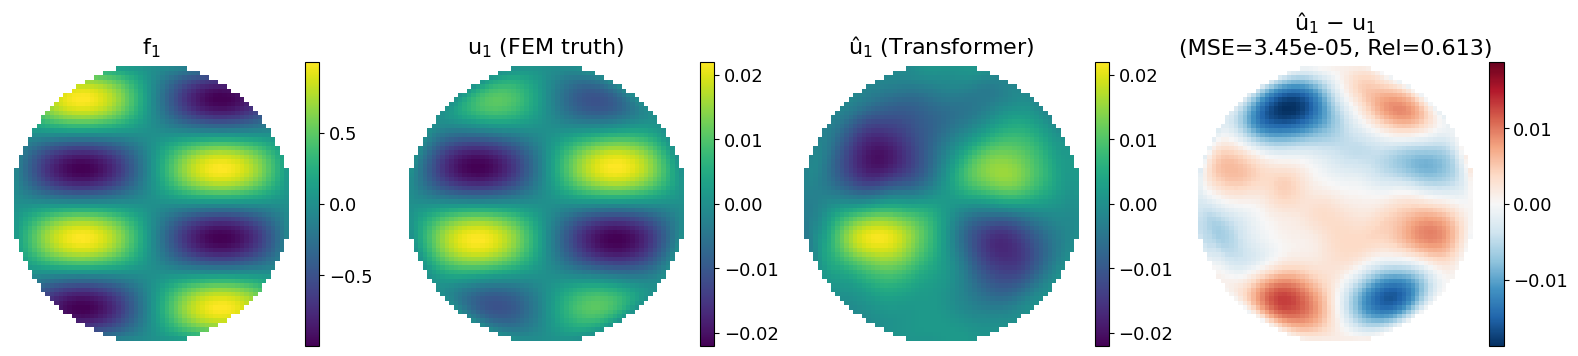

✓ Saved visualization to transformer_sin_1_2.png
[mix                   ] MSE=5.523e-05 | RelL2=3.550e-01


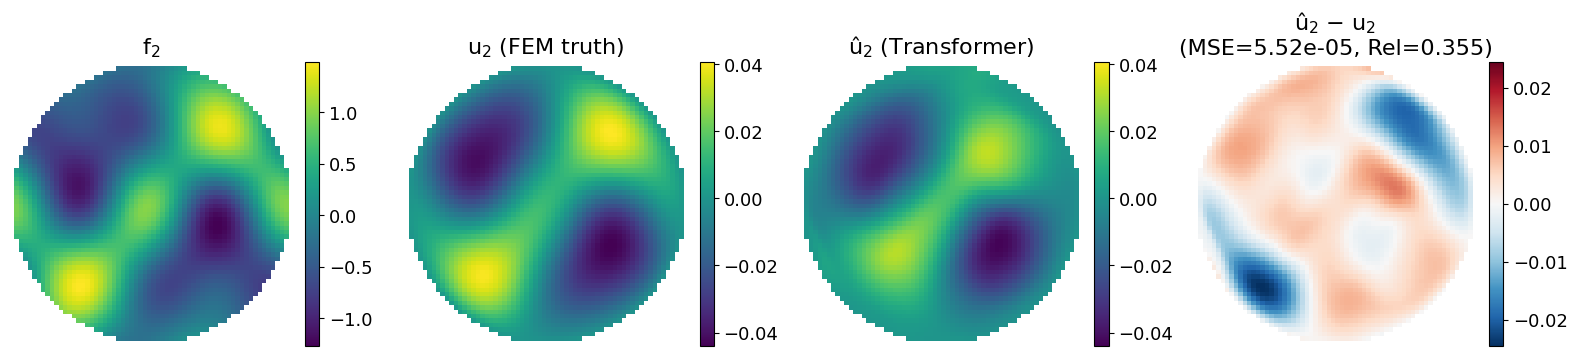

✓ Saved visualization to transformer_mix.png
[sin_3_3               ] MSE=1.362e-05 | RelL2=1.328e+00


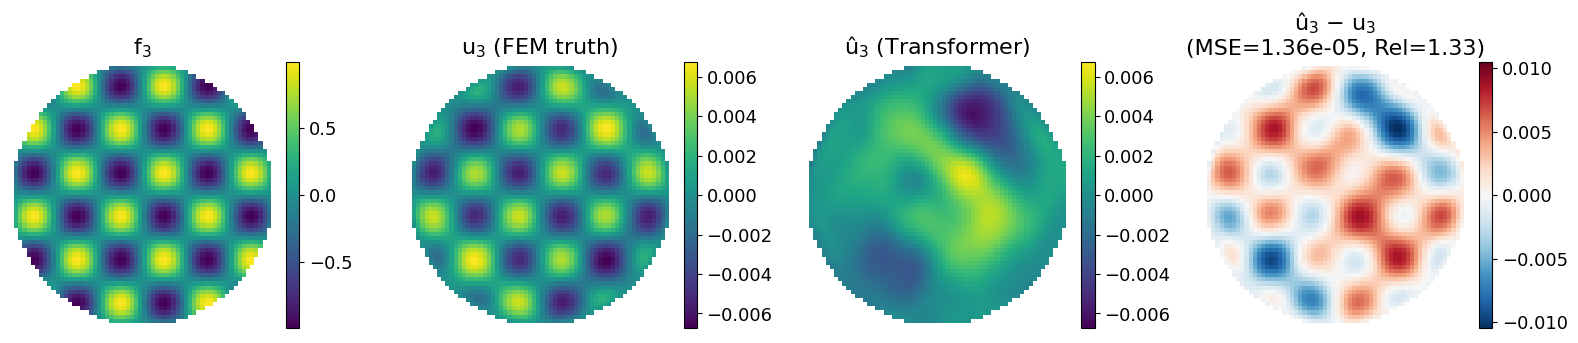

✓ Saved visualization to transformer_sin_3_3.png
[sin_5_x               ] MSE=3.434e-05 | RelL2=2.121e+00


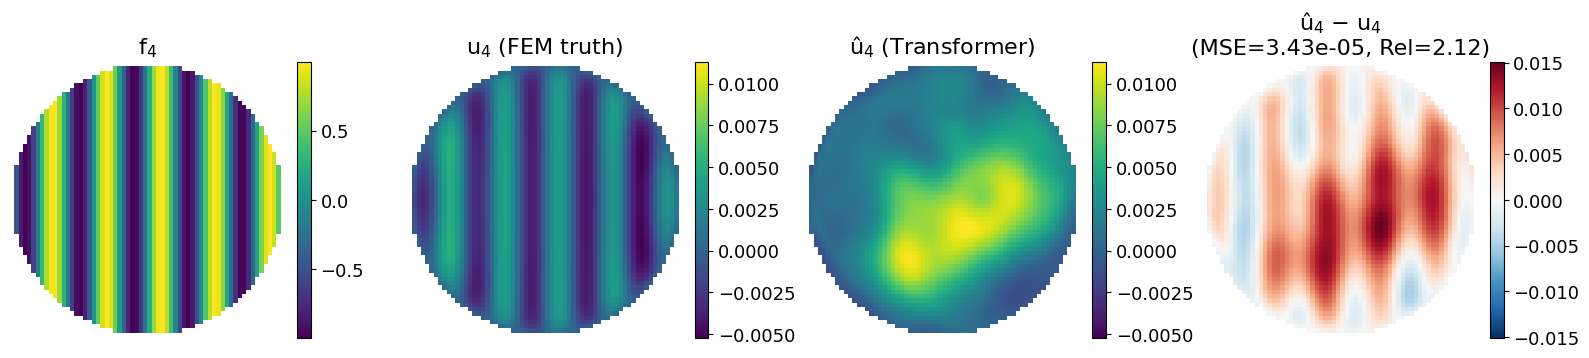

✓ Saved visualization to transformer_sin_5_x.png
✓ Saved metrics to transformer_customf_metrics.txt


In [ ]:
print("\n[Extra] Transformer custom f tests (same as DeepONet / FNO) ...")
_ = run_custom_f_tests_transformer(
    model=transformer,
    grid_size=GRID_SIZE,
    radius=RADIUS,
    device=DEVICE
)